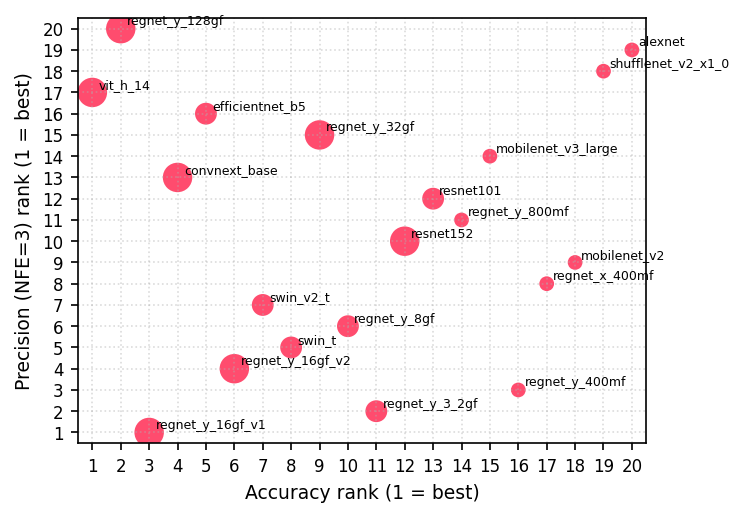

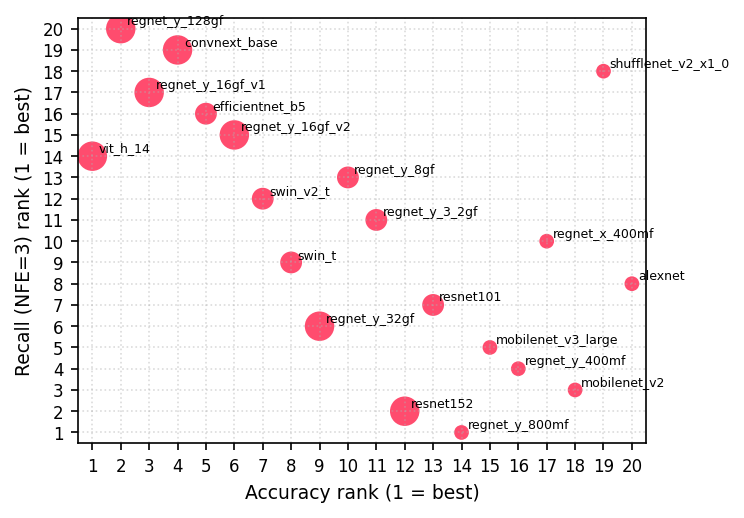

In [11]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------- 데이터 ----------
raw = [
  ("vit_h_14",98.694,1016.72), ("regnet_y_128gf",97.844,127.52),
  ("regnet_y_16gf_v1",97.244,15.91), ("convnext_base",96.870,15.36),
  ("efficientnet_b5",96.628,10.27), ("regnet_y_16gf_v2",96.328,15.91),
  ("swin_v2_t",96.132,5.94), ("swin_t",95.776,4.49),
  ("regnet_y_32gf",95.340,32.28), ("regnet_y_8gf",95.048,8.47),
  ("regnet_y_3_2gf",94.576,3.18), ("resnet152",94.046,11.51),
  ("resnet101",93.546,7.80), ("regnet_y_800mf",93.136,0.83),
  ("mobilenet_v3_large",92.566,0.22), ("regnet_y_400mf",91.716,0.40),
  ("regnet_x_400mf",90.950,0.41), ("mobilenet_v2",90.286,0.30),
  ("shufflenet_v2_x1_0",88.316,0.14), ("alexnet",79.066,0.71),
]
names  = np.array([r[0] for r in raw])
acc5   = np.array([r[1] for r in raw], float)
gflops = np.array([r[2] for r in raw], float)
N = len(names)

# ----- NFE=3 metrics -----
precision3 = np.array([0.8376,0.8230,0.8573,0.8529,0.8379,0.8559,0.8555,0.8559,0.8520,0.8559,0.8564,0.8537,0.8529,0.8532,0.8523,0.8560,0.8553,0.8541,0.8368,0.8300])
recall3    = np.array([0.7420,0.7327,0.7392,0.7359,0.7393,0.7396,0.7439,0.7448,0.7464,0.7438,0.7448,0.7493,0.7459,0.7508,0.7467,0.7470,0.7448,0.7471,0.7388,0.7455])

# ----- 랭크 (1=best) -----
acc_rank = np.empty(N,int); acc_rank[np.argsort(-acc5)] = np.arange(1,N+1)

def to_rank_desc(y):  # 큰 값이 좋음
    r = np.empty(N,int); r[np.argsort(-y)] = np.arange(1,N+1); return r

r_prec3 = to_rank_desc(precision3)
r_rec3  = to_rank_desc(recall3)

# ----- GFLOPS → 마커 크기 (3 log-분위 bin) -----
lx = np.log10(gflops + 1e-12)
edges = 10**np.quantile(lx, [0, 1/3, 2/3, 1])
sizes = np.array([50, 110, 200], float)
svals = sizes[np.clip(np.digitize(gflops, edges) - 1, 0, 2)]

def rank_plot_single(y_rank, ylabel, color, legend_loc=(0.5, 0.56)):
    fig, ax = plt.subplots(figsize=(5.0,3.5), dpi=150)
    ax.scatter(acc_rank, y_rank, s=svals, c=color, alpha=.85, edgecolors="none")

    # 라벨(옵션): 포인트에 모델명
    for x,y,t in zip(acc_rank, y_rank, names):
        ax.annotate(t, (x,y), xytext=(3,2), textcoords="offset points", fontsize=6)

    ticks = np.arange(1, N+1)
    ax.set_xlim(.5, N+.5); ax.set_ylim(.5, N+.5)
    ax.set_xticks(ticks); ax.set_yticks(ticks)
    ax.set_xlabel("Accuracy rank (1 = best)")
    ax.set_ylabel(f"{ylabel} rank (1 = best)")
    ax.grid(True, ls=":", alpha=.45)

    # GFLOPS size-bin legend
    size_handles = []
    for i in range(3):
        lo, hi = edges[i], edges[i+1]
        lbl = f"{lo:.2g}–{hi:.2g} GFLOPS" if i < 2 else f">={lo:.2g} GFLOPS"
        size_handles.append(Line2D([0],[0], marker='o', linestyle='',
                                   markersize=(sizes[i]**0.5)*0.6, markerfacecolor="#888",
                                   markeredgecolor='none', label=lbl))
    #ax.legend(handles=size_handles, bbox_to_anchor=legend_loc, framealpha=.9, fontsize=8, title="GFLOPS bins")
    plt.tight_layout(); plt.show()

# ---- NFE=3만 출력 ----
rank_plot_single(r_prec3, "Precision (NFE=3)", color="#FF2D55")
rank_plot_single(r_rec3,  "Recall (NFE=3)",    color="#FF2D55")


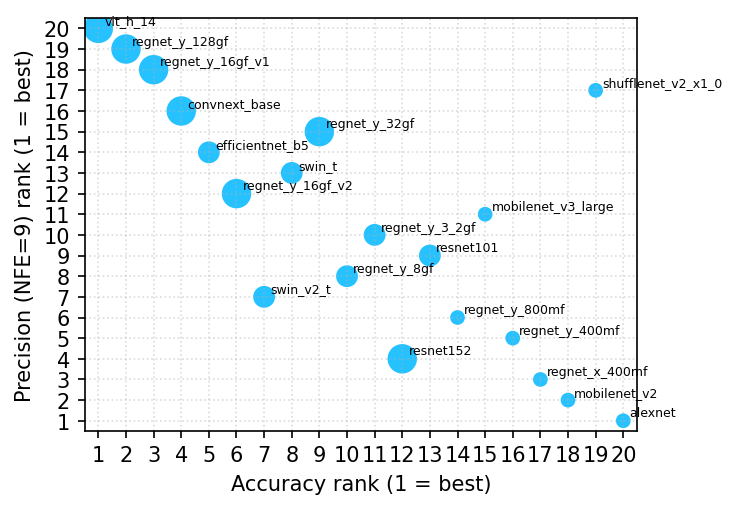

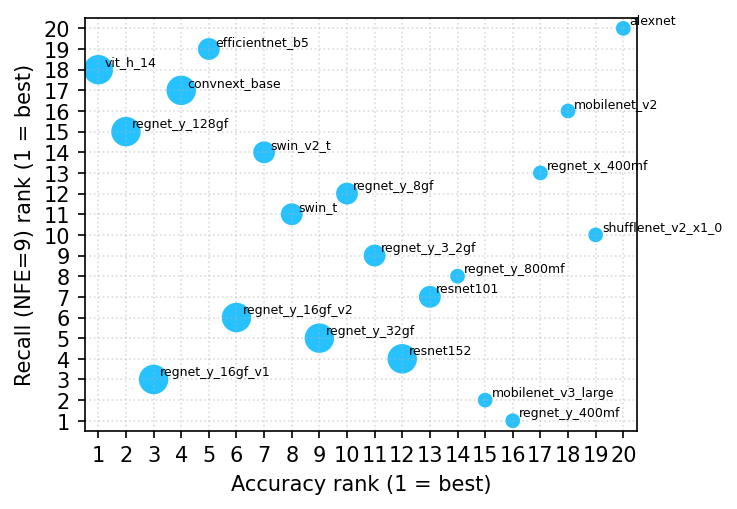

In [2]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------- 데이터 (동일) ----------
raw = [
  ("vit_h_14",98.694,1016.72), ("regnet_y_128gf",97.844,127.52),
  ("regnet_y_16gf_v1",97.244,15.91), ("convnext_base",96.870,15.36),
  ("efficientnet_b5",96.628,10.27), ("regnet_y_16gf_v2",96.328,15.91),
  ("swin_v2_t",96.132,5.94), ("swin_t",95.776,4.49),
  ("regnet_y_32gf",95.340,32.28), ("regnet_y_8gf",95.048,8.47),
  ("regnet_y_3_2gf",94.576,3.18), ("resnet152",94.046,11.51),
  ("resnet101",93.546,7.80), ("regnet_y_800mf",93.136,0.83),
  ("mobilenet_v3_large",92.566,0.22), ("regnet_y_400mf",91.716,0.40),
  ("regnet_x_400mf",90.950,0.41), ("mobilenet_v2",90.286,0.30),
  ("shufflenet_v2_x1_0",88.316,0.14), ("alexnet",79.066,0.71),
]
names  = np.array([r[0] for r in raw])
acc5   = np.array([r[1] for r in raw], float)
gflops = np.array([r[2] for r in raw], float)
N = len(names)

# ----- NFE=9 metrics -----
precision9 = np.array([
 0.8960,0.8996,0.9007,0.9040,0.9048,0.9061,0.9078,0.9055,0.9043,0.9074,
 0.9065,0.9089,0.9067,0.9081,0.9062,0.9082,0.9091,0.9118,0.9017,0.9163
], dtype=float)
recall9 = np.array([
 0.7311,0.7336,0.7467,0.7327,0.7310,0.7455,0.7410,0.7425,0.7455,0.7414,
 0.7436,0.7459,0.7454,0.7437,0.7475,0.7489,0.7410,0.7331,0.7436,0.7187
], dtype=float)

# ----- 랭크 (1=best) -----
acc_rank = np.empty(N,int); acc_rank[np.argsort(-acc5)] = np.arange(1,N+1)
def to_rank_desc(y): r = np.empty(N,int); r[np.argsort(-y)] = np.arange(1,N+1); return r
r_prec9 = to_rank_desc(precision9)
r_rec9  = to_rank_desc(recall9)

# ----- GFLOPS → 마커 크기 (3 log-분위 bin) -----
lx = np.log10(gflops + 1e-12)
edges = 10**np.quantile(lx, [0, 1/3, 2/3, 1])
sizes = np.array([50, 110, 200], float)
svals = sizes[np.clip(np.digitize(gflops, edges) - 1, 0, 2)]

def rank_plot_single(y_rank, ylabel, color):
    fig, ax = plt.subplots(figsize=(5.0,3.5), dpi=150)
    ax.scatter(acc_rank, y_rank, s=svals, c=color, alpha=.85, edgecolors="none")

    for x,y,t in zip(acc_rank, y_rank, names):
        ax.annotate(t, (x,y), xytext=(3,2), textcoords="offset points", fontsize=6)

    ticks = np.arange(1, N+1)
    ax.set_xlim(.5, N+.5); ax.set_ylim(.5, N+.5)
    ax.set_xticks(ticks); ax.set_yticks(ticks)
    ax.set_xlabel("Accuracy rank (1 = best)")
    ax.set_ylabel(f"{ylabel} rank (1 = best)")
    ax.grid(True, ls=":", alpha=.45)
    plt.tight_layout(); plt.show()

# ---- NFE=9만 출력 ----
rank_plot_single(r_prec9, "Precision (NFE=9)", color="#00B8FF")
rank_plot_single(r_rec9,  "Recall (NFE=9)",    color="#00B8FF")
